In [ ]:
import networkx as nx
try:
    facebook_net = nx.read_edgelist('facebook_combined.txt',
                                     create_using=nx.Graph(),
                                     nodetype=int)

    print(f"Facebook Network Loaded!")
    print(f"Nodes: {facebook_net.number_of_nodes()}")
    print(f"Edges: {facebook_net.number_of_edges()}")
    print(f"Density: {nx.density(facebook_net):.6f}")

    # Calculate centralities (sample for large networks)
    print("\\nCalculating degree centrality...")
    degree_fb = nx.degree_centrality(facebook_net)

    # For large networks, use sampling for betweenness
    print("Calculating betweenness (sampled)...")
    betweenness_fb = nx.betweenness_centrality(facebook_net, k=100)

    # Find top nodes
    top_degree = sorted(degree_fb.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\\nTop 10 nodes by degree centrality:")
    for node, cent in top_degree:
        print(f"Node {node}: {cent:.4f}")

except FileNotFoundError:
    print("File not found. Please download from SNAP first.")

Facebook Network Loaded!
Nodes: 4039
Edges: 88234
Density: 0.010820
\nCalculating degree centrality...
Calculating betweenness (sampled)...
\nTop 10 nodes by degree centrality:
Node 107: 0.2588
Node 1684: 0.1961
Node 1912: 0.1870
Node 3437: 0.1355
Node 0: 0.0859
Node 2543: 0.0728
Node 2347: 0.0721
Node 1888: 0.0629
Node 1800: 0.0607
Node 1663: 0.0582


In [ ]:
import pandas as pd
import networkx as nx

# Centrality calculations
print("Calculating degree centrality...")
degree_fb = nx.degree_centrality(facebook_net)

print("Calculating closeness centrality...")
closeness_fb = nx.closeness_centrality(facebook_net)

print("Calculating betweenness centrality (sampled)...")
betweenness_fb = nx.betweenness_centrality(facebook_net, k=200, seed=42)

print("Calculating PageRank...")
pagerank_fb = nx.pagerank(facebook_net, alpha=0.85)

# Combine into a DataFrame
centrality_df = pd.DataFrame({
    'Degree': pd.Series(degree_fb),
    'Closeness': pd.Series(closeness_fb),
    'Betweenness': pd.Series(betweenness_fb),
    'PageRank': pd.Series(pagerank_fb)
})

# Normalize for easier comparison
centrality_df = centrality_df / centrality_df.max()

# Show top 10 by degree
top10 = centrality_df.sort_values('Degree', ascending=False).head(10)
print(top10)

Calculating degree centrality...
Calculating closeness centrality...
Calculating betweenness centrality (sampled)...
Calculating PageRank...
        Degree  Closeness  Betweenness  PageRank
107   1.000000   1.000000     1.000000  0.910939
1684  0.757895   0.856224     0.735101  0.836180
1912  0.722488   0.763428     0.460839  0.509151
3437  0.523445   0.683952     0.436639  1.000000
0     0.332057   0.768638     0.300355  0.825994
2543  0.281340   0.633675     0.012129  0.088398
2347  0.278469   0.616508     0.005138  0.082585
1888  0.243062   0.698918     0.000354  0.093468
1800  0.234450   0.699586     0.000584  0.091727
1663  0.224880   0.737841     0.002769  0.087271


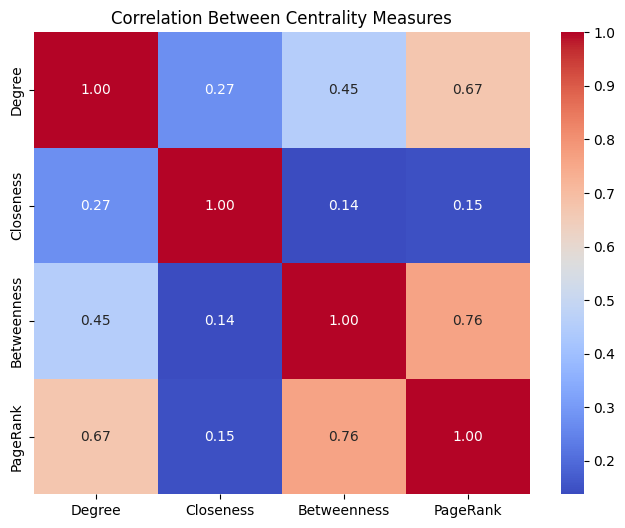

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(centrality_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Centrality Measures")
plt.show()


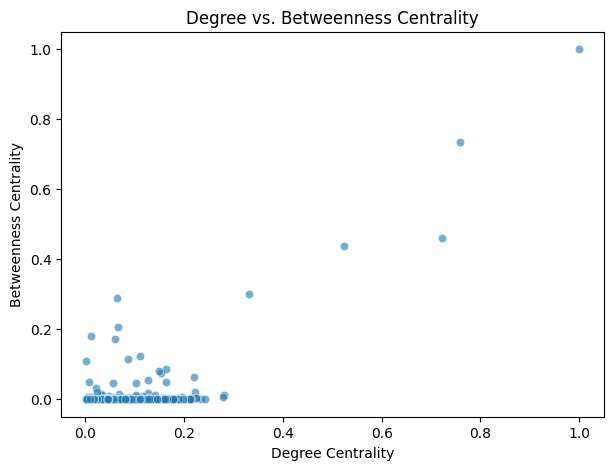

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Degree', y='Betweenness', data=centrality_df, alpha=0.6)
plt.title("Degree vs. Betweenness Centrality")
plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
plt.show()


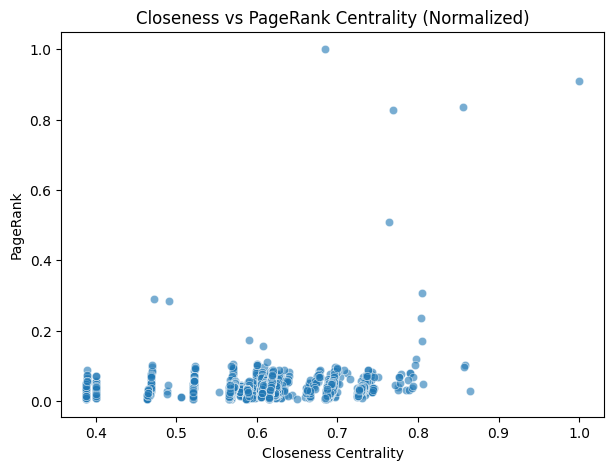

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='Closeness', y='PageRank', data=centrality_df, alpha=0.6)
plt.title("Closeness vs PageRank Centrality (Normalized)")
plt.xlabel("Closeness Centrality")
plt.ylabel("PageRank")
plt.show()

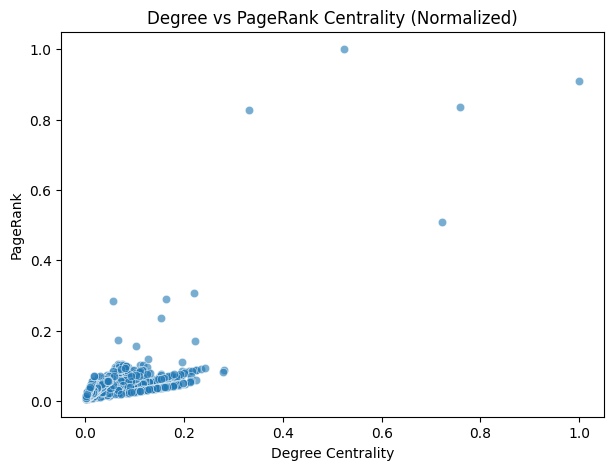

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='Degree', y='PageRank', data=centrality_df, alpha=0.6)
plt.title("Degree vs PageRank Centrality (Normalized)")
plt.xlabel("Degree Centrality")
plt.ylabel("PageRank")
plt.show()

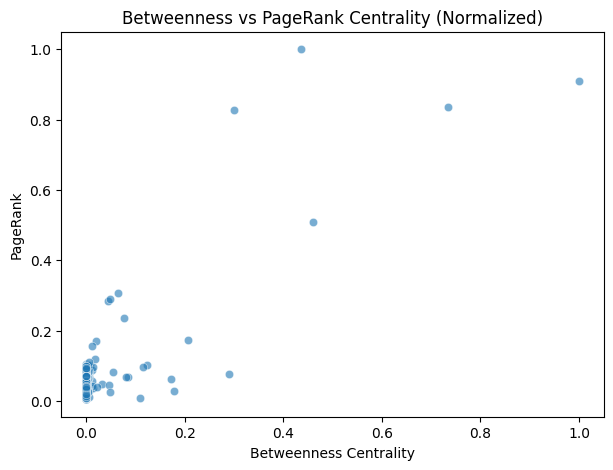

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='Betweenness', y='PageRank', data=centrality_df, alpha=0.6)
plt.title("Betweenness vs PageRank Centrality (Normalized)")
plt.xlabel("Betweenness Centrality")
plt.ylabel("PageRank")
plt.show()

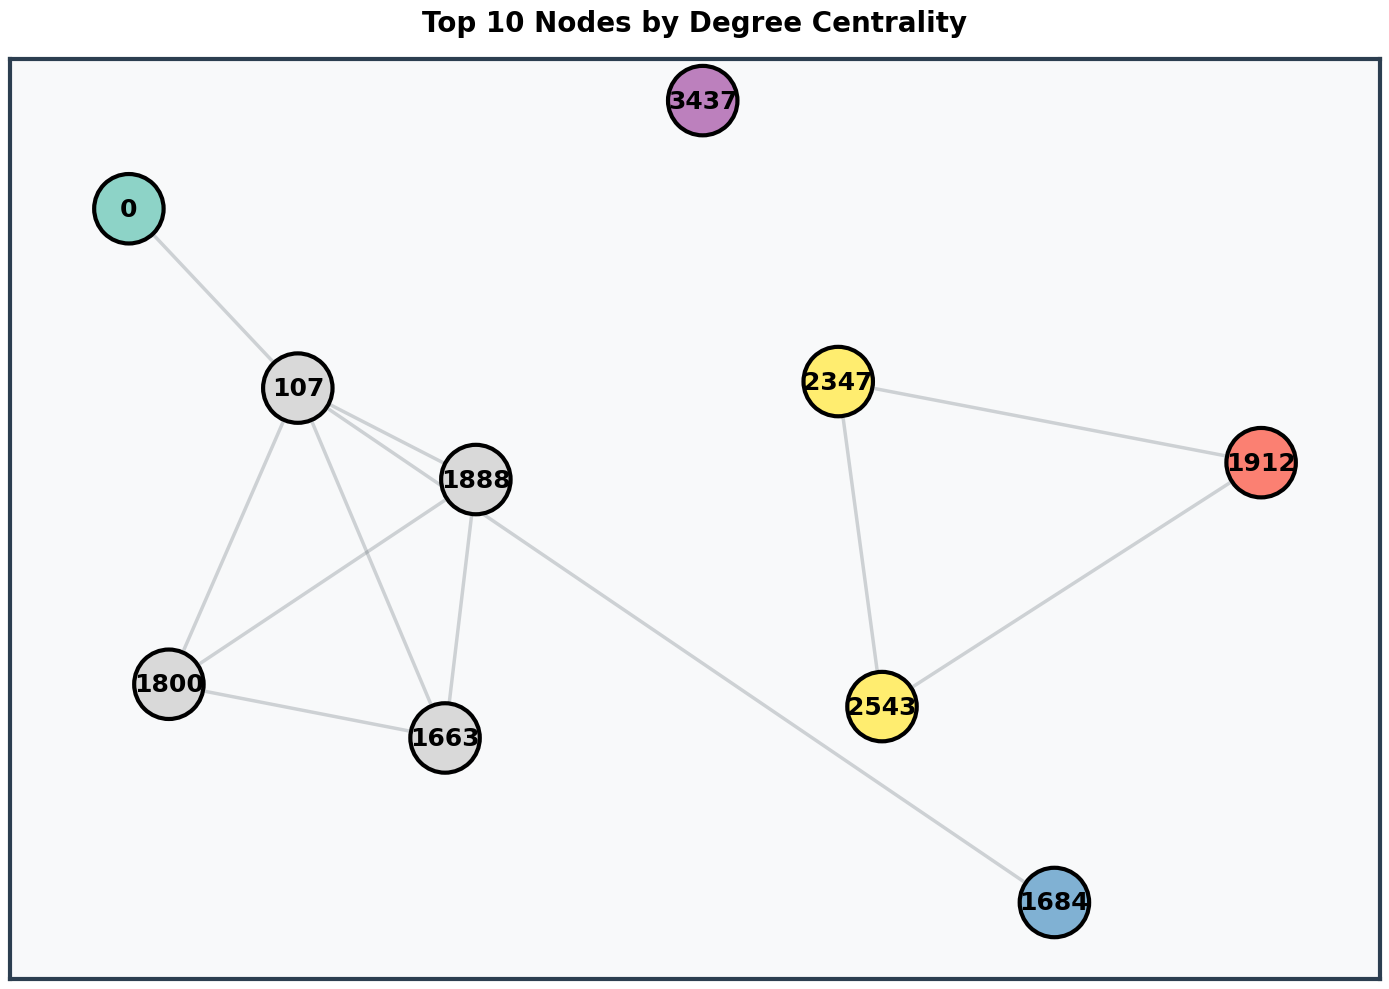

In [ ]:
# Top 10 nodos por Degree Centrality - Versión Mejorada con Marco Visible
top_nodes = centrality_df.sort_values('Degree', ascending=False).head(10).index
subgraph = facebook_net.subgraph(top_nodes)

# Asignar colores por comunidad
node_colors = [partition[node] for node in subgraph.nodes()]

# Configurar figura con fondo blanco y marco
fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
ax.set_facecolor('#f8f9fa')

# Layout mejorado con mayor separación entre comunidades
pos = nx.spring_layout(subgraph, k=3.5, iterations=100, seed=42, weight=None)

# Ajuste adicional: separar manualmente por comunidades si es necesario
communities_in_subgraph = {}
for node in subgraph.nodes():
    comm = partition[node]
    if comm not in communities_in_subgraph:
        communities_in_subgraph[comm] = []
    communities_in_subgraph[comm].append(node)

# Si hay múltiples comunidades, aplicar un desplazamiento por grupo
if len(communities_in_subgraph) > 1:
    community_list = list(communities_in_subgraph.keys())
    for idx, comm in enumerate(community_list):
        offset_x = (idx - len(community_list)/2) * 0.8
        offset_y = (idx % 2) * 0.4
        for node in communities_in_subgraph[comm]:
            pos[node][0] += offset_x
            pos[node][1] += offset_y

# Dibujar edges con mejor estética
nx.draw_networkx_edges(subgraph, pos,
                       width=2.5,
                       alpha=0.3,
                       edge_color='#6c757d',
                       ax=ax)

# Dibujar nodos con colores por comunidad y borde definido
nx.draw_networkx_nodes(subgraph, pos,
                       node_size=2500,
                       node_color=node_colors,
                       cmap=plt.cm.Set3,
                       edgecolors='black',
                       linewidths=3,
                       ax=ax)

# Dibujar etiquetas con mejor tipografía y tamaño
nx.draw_networkx_labels(subgraph, pos,
                       font_size=18,
                       font_weight='bold',
                       font_family='sans-serif',
                       ax=ax)

# Título con mejor formato
ax.set_title('Top 10 Nodes by Degree Centrality',
            fontsize=20,
            fontweight='bold',
            pad=20,
            fontfamily='sans-serif')

# Ocultar ticks y etiquetas de los ejes pero mantener el marco
ax.set_xticks([])
ax.set_yticks([])

# Agregar marco decorativo visible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('#2c3e50')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

Computing layout (this may take a while)...


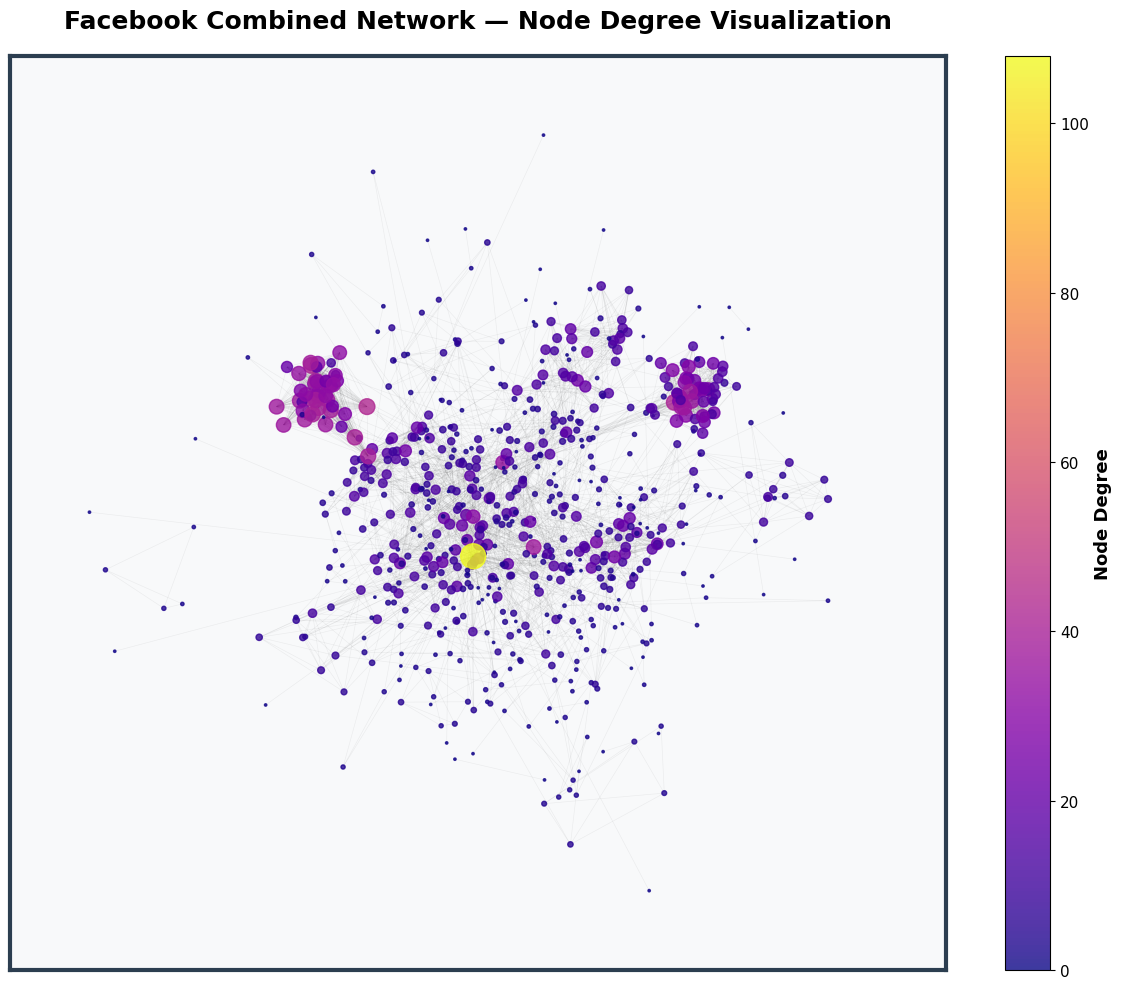

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Choose layout – spring_layout is good for small/medium graphs
# For large graphs, use a faster approximation:
print("Computing layout (this may take a while)...")
pos = nx.spring_layout(facebook_net, k=0.15, iterations=20, seed=42)

# Optional: visualize only a subset for speed
sub_nodes = np.random.choice(facebook_net.nodes(), size=800, replace=False)
G = facebook_net.subgraph(sub_nodes)
# G = facebook_net  # full network

# Use degree for node size and color scaling
degree_dict = dict(G.degree())
sizes = [v * 3 for v in degree_dict.values()]  # scale factor
colors = [v for v in degree_dict.values()]

# Crear figura con fondo mejorado
fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
ax.set_facecolor('#f8f9fa')

nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.5, ax=ax)
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=sizes,
    node_color=colors,
    cmap=plt.cm.plasma,
    alpha=0.8,
    ax=ax
)

# Add colorbar and title con mejor tipografía
cbar = plt.colorbar(nodes, label="Node Degree", ax=ax)
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Node Degree", fontsize=13, fontweight='bold', fontfamily='sans-serif')

ax.set_title("Facebook Combined Network — Node Degree Visualization",
            fontsize=18,
            fontweight='bold',
            pad=20,
            fontfamily='sans-serif')

# Ocultar ticks pero mantener el marco
ax.set_xticks([])
ax.set_yticks([])

# Agregar marco decorativo visible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('#2c3e50')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Local Clustering Coefficient
# Returns a dictionary where the key is the node and the value is its coefficient.
print("Calculating Clustering Coefficient...")
clustering_coefficient = nx.clustering(facebook_net)

# 2. Convert to a Pandas Series for easier analysis and visualization
clustering_series = pd.Series(clustering_coefficient)

# Print some key statistics
print(f"Average Clustering Coefficient: {clustering_series.mean():.4f}")
print(f"Median Clustering Coefficient: {clustering_series.median():.4f}")

Calculating Clustering Coefficient...
Average Clustering Coefficient: 0.6055
Median Clustering Coefficient: 0.6000


/tmp/ipython-input-978440864.py:23: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-978440864.py:23: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


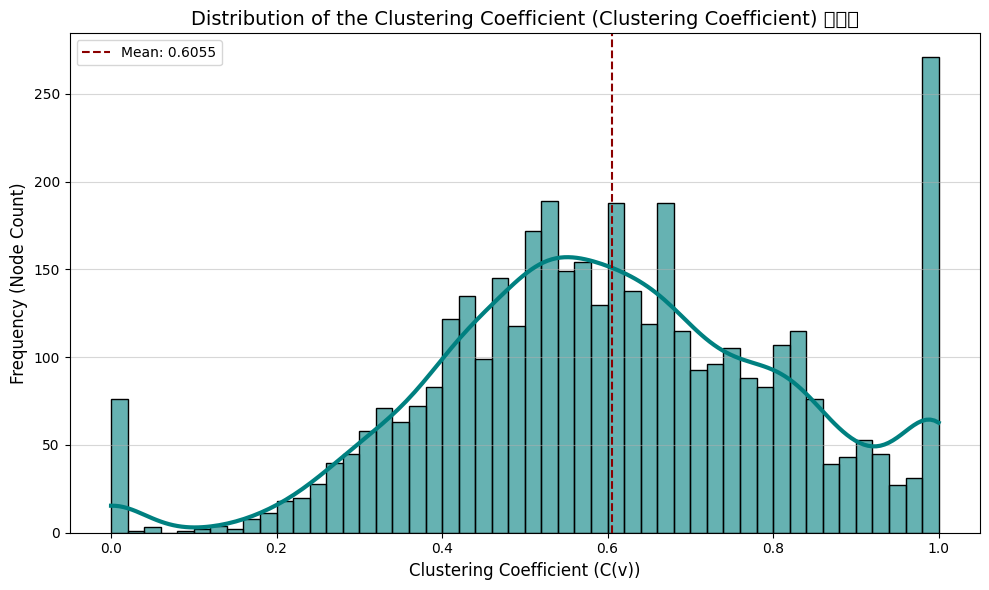

In [ ]:
# Create the figure and subplots
plt.figure(figsize=(10, 6))

# Draw the histogram and KDE
# Histogram: Shows the frequency of values in different 'bins'.
# KDE (Kernel Density Estimate): Is a smooth curve that estimates the probability density function.
sns.histplot(
    clustering_series,
    bins=50, # Number of bins for the histogram
    kde=True, # Add the density line
    color='teal',
    alpha=0.6,
    line_kws={'linewidth': 3, 'color': 'darkred'} # Style of the KDE line
)

# Add labels and title
plt.title("Distribution of the Clustering Coefficient (Clustering Coefficient) 🧑‍🤝‍🧑", fontsize=14)
plt.xlabel("Clustering Coefficient (C(v))", fontsize=12)
plt.ylabel("Frequency (Node Count)", fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.axvline(clustering_series.mean(), color='darkred', linestyle='--', linewidth=1.5, label=f'Mean: {clustering_series.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 1. Detect the best partition (communities)
print("Calculating the best partition of the network using the Louvain Algorithm...")
# The result is a dictionary where the key is the node and the value is its community ID
partition = community_louvain.best_partition(facebook_net)

# 2. Get the number of communities and modularity
num_communities = max(partition.values()) + 1
modularity = community_louvain.modularity(partition, facebook_net)

print(f"Total number of communities detected: {num_communities}")
print(f"Modularity of the partition: {modularity:.4f} (A high value indicates a strong community structure)")

Calculating the best partition of the network using the Louvain Algorithm...
Total number of communities detected: 16
Modularity of the partition: 0.8350 (A high value indicates a strong community structure)


Computando layout y dibujando la muestra de red...


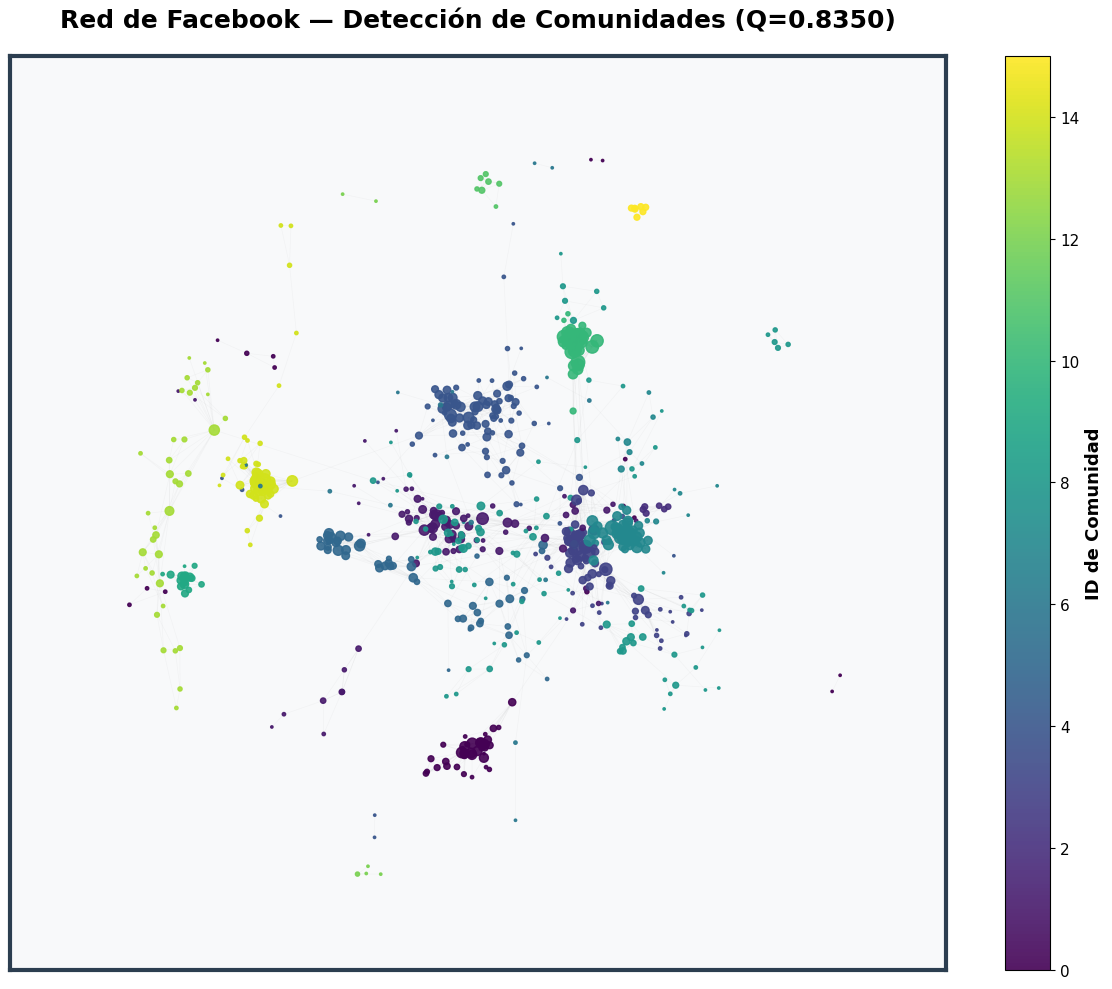

In [ ]:
# Variables usadas en tu código original para el muestreo
sub_nodes = np.random.choice(facebook_net.nodes(), size=800, replace=False)
G_sample = facebook_net.subgraph(sub_nodes)

# Posiciones de los nodos (usamos el mismo layout para mantener la coherencia)
print("Computando layout y dibujando la muestra de red...")
pos = nx.spring_layout(G_sample, k=0.15, iterations=20, seed=42)

# Colores y tamaños:
# - Color: Determinado por la Comunidad (Partition ID)
# - Tamaño: Puedes mantenerlo basado en el Grado (Degree) para doble información
node_colors = [partition[node] for node in G_sample.nodes()]
degree_dict = dict(G_sample.degree())
sizes = [v * 3 for v in degree_dict.values()]

# Crear figura con fondo mejorado
fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
ax.set_facecolor('#f8f9fa')

# 1. Dibujar las aristas
nx.draw_networkx_edges(G_sample, pos, alpha=0.05, width=0.5, edge_color='gray', ax=ax)

# 2. Dibujar los nodos, usando la partición para el color
nodes = nx.draw_networkx_nodes(
    G_sample, pos,
    node_size=sizes,
    node_color=node_colors, # Usamos el ID de la comunidad para colorear
    cmap=plt.cm.viridis,    # El mapa de color 'viridis' es excelente
    alpha=0.9,
    ax=ax
)

# Añadir colorbar y título con mejor tipografía
cbar = plt.colorbar(nodes, label="ID de Comunidad", ax=ax)
cbar.ax.tick_params(labelsize=11)
cbar.set_label("ID de Comunidad", fontsize=13, fontweight='bold', fontfamily='sans-serif')

ax.set_title(f"Red de Facebook — Detección de Comunidades (Q={modularity:.4f})",
            fontsize=18,
            fontweight='bold',
            pad=20,
            fontfamily='sans-serif')

# Ocultar ticks pero mantener el marco
ax.set_xticks([])
ax.set_yticks([])

# Agregar marco decorativo visible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('#2c3e50')
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()

# Insights

## Which nodes are most central and why?
The most central nodes in the Facebook network are 107, 1684, 1912, and 3437.

- Node 107 ranks highest across all metrics — degree, closeness, betweenness, and PageRank — indicating it’s both highly connected and strategically positioned within the network.

- Nodes 1684 and 1912 also have strong degree and PageRank values, meaning they have many direct connections and are linked to other influential users.

- Node 3437, while not having the highest degree, achieves the maximum PageRank, suggesting it connects to other highly ranked individuals and plays a key role in the spread of information.

These nodes likely act as social hubs or connectors among multiple friend communities — users who bridge otherwise separated clusters.

## How do different centrality metrics compare?
Measured correlations show:

- Degree ↔ PageRank: 0.67

- Closeness ↔ Betweenness: 0.14

- Betweenness ↔ PageRank: 0.76

Degree and PageRank are moderately correlated, meaning popular users are often influential, but not always. Influence depends on who you are connected to, not just how many friends you have.

Closeness and Betweenness are weakly correlated, it turns out users who are globally close to others aren’t necessarily acting as bridges between communities.

Betweenness and PageRank are strongly correlated, therefore we can conclude that bridge nodes that connect different communities also tend to be influential in the overall information flow.

This pattern suggests influence in the network emerges from connectivity between groups, not just internal popularity.

## What does this tell us about the network structure?
The Facebook network shows a community-based, small-world structure:

Many dense, tightly connected clusters (friend groups).

A few key individuals linking those clusters — visible through high betweenness and PageRank.

The overall density (≈0.0108) confirms it’s sparse but efficiently connected.

Such a topology reflects real social dynamics — people form small, overlapping social circles with a few bridges ensuring global connectivity. The network is thus robust within communities but vulnerable to the removal of key connectors.

## What real-world insights can we derive?
**Influece Targeting**: High-PageRank users (e.g., 107, 3437) are optimal for information diffusion, viral marketing, or awareness campaigns.

**Network resilience**: High-betweenness users are structural bridges — losing them could fragment the community graph.

**Community detection**: Centrality differences highlight where clusters and boundaries exist, guiding friend recommendations or subgroup analyses.

**Social behavior insight**: The balance between degree and betweenness suggests people who connect multiple groups tend to have higher influence, even without being the most popular locally.

## Additional Metrics

Based on the outcomes about Clustering Coefficient we can see a high tendency to form cliques, in other words, if two people know the same individual, there is a 60% chance that they know each other. Additionally, the graph distribution is Bimodal (it has two peaks). There is a large peak around the mean ($0.6$), but there is another significant peak at $C(v) = 1.0$.

The peak at $1.0$ represents a large number of nodes that have perfect clustering. That is, all their neighbors are connected to each other, forming closed groups (almost cliques or cliques).

This pattern confirms that the network is a “Small World,” where the average distance between nodes is small (high efficiency) and, at the same time, the nodes are strongly clustered locally (high social structure).


Finally, we can see modularity confirms that ties within communities are much denser than ties between communities. The network has 16 groups, and it can be observed that nodes of the same color (same community) are geographically very close to each other and have few ties crossing color boundaries. This visually confirms the high degree of modularity: Facebook users tend to interact almost exclusively with members of their own social group.

